In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import modelWithPersonas as mod
from utils import *

In [2]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

Current working directory: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\notebooks
Path to experiment files: ../results/experiments/
c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments


In [3]:
openai.__version__

'1.50.2'

In [4]:
# set simulation parameters
# disabling seed in this case
# isolate personality from seeding
#seed = 0
#np.random.seed(seed)
seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 50
#n_steps = 5
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

In [5]:
np.random.seed(1)
print(np.random.rand(3))

[4.17022005e-01 7.20324493e-01 1.14374817e-04]


# Positive feedback

In [6]:
expmnt_num = 0
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_0_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 0.


In [7]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Experiment Fingerprints: b6d4122e8155c6a66e45d4f074371de4
 
 Time: 0, agent: 0, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a conservative estimate based on historical averages to promote market stability.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a stable initial prediction close to the historical average. By aiming for stability, I hope to influence long-term market behavior positively.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will st

In [8]:
feedback='pos'
for i in range(1, 11):
    expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Experiment Fingerprints: b6d4122e8155c6a66e45d4f074371de4
 
 Time: 0, agent: 0, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Stability is key in my predictions. I will start with the historical average as my initial prediction.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1, persona: Fundamentalist Trader 

{'role': 'user', 'content': 'This is the firs

In [10]:
pe_agents_time_op.shape

(5, 50)

Text(0.5, 0, 'Time step')

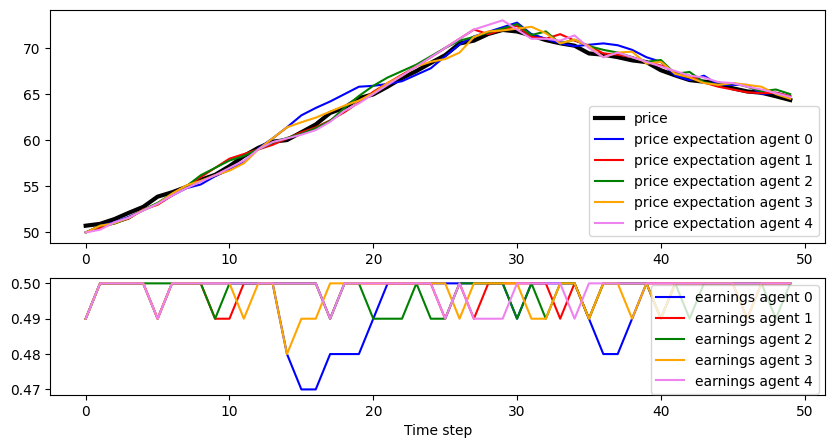

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_op,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_op[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_op[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

Seed = 0 
First fingerprint = 17ea0e8cd5950b3ad6a70158552235d5
Second fingerprint = 17ea0e8cd5950b3ad6a70158552235d5

In [11]:
# df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_ntime_50_nagents_5.csv")
df = pd.read_csv("../results/experiments/expmnt_results_pos_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv")

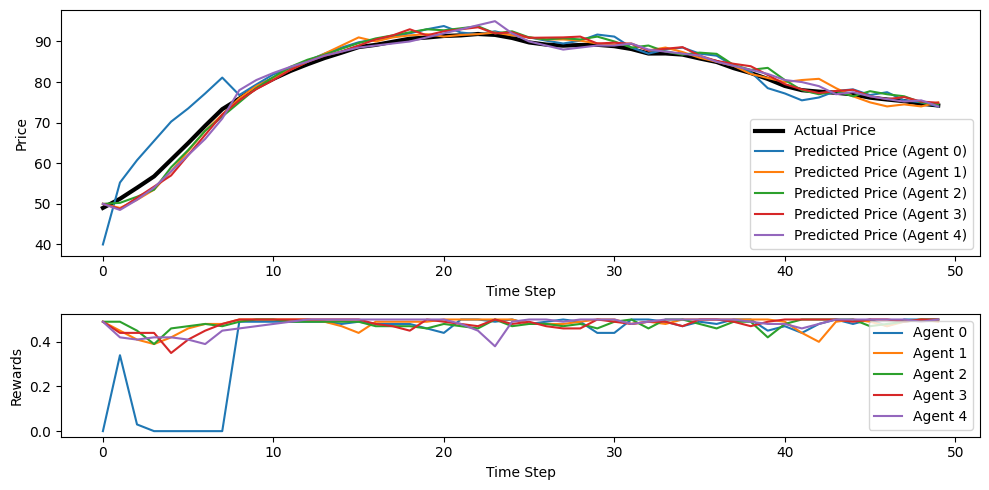

In [12]:
# Create figure and subplots
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})

# Plot actual and predicted prices over time_step
axs[0].plot(df['time_step'], df['actual_price'], label='Actual Price', color="black",linewidth = 3)
for agent_id, group in df.groupby('agent_id'):
    axs[0].plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('Price')
axs[0].legend()

# Plot rewards by agent_id over time_step
for agent_id, group in df.groupby('agent_id'):
    axs[1].plot(group['time_step'], group['rewards'], label=f'Agent {agent_id}')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Rewards')
axs[1].legend()

plt.tight_layout()
plt.show()

# Negative feedback

In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']
# Set a global seed for reproducibility 
# GLOBAL_SEED = 42
# np.random.seed(GLOBAL_SEED)
# random.seed(GLOBAL_SEED)

#from model import *
import modelWithPersonas as mod
from utils import *

In [2]:
path_exp = '../results/experiments/'

print(f"Current working directory: {os.getcwd()}")
print(f"Path to experiment files: {path_exp}")
print(os.path.abspath("../results/experiments"))

Current working directory: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\notebooks
Path to experiment files: ../results/experiments/
c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments


In [4]:
# set simulation parameters
# disabling seed in this case
# isolate personality from seeding
#seed = 0
#np.random.seed(seed)
seed = None
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 5
n_steps = 50
#n_steps = 5
gpt_model="gpt-3.5-turbo-0125"
#gpt_model="gpt-3.5-turbo-1106"

In [5]:
expmnt_num = 1
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)

Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.


In [6]:
# list of personas to test
# persona_types = [
#     "Aggressive Speculator",
#     "Momentum Trader",
#     "Balanced Decision-Maker",
#     "Market Analyst",
#     "Contrarian Investor",
#     "Fundamentalist Trader"
# ]

persona_types = [
    "Momentum Trader"
]

In [7]:
for persona in persona_types:
    batch_folder = create_batch_folder(persona)
    print(f"\nRunning experiments for persona: {persona}")

    for i in range(1, 11):
        expmnt_num = check_existing_file(path_exp, i, feedback, instruction_type, temperature, memory, n_steps, n_agents, gpt_model)
        print(f"Running experiment {i} for {persona}...")
        
        p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=batch_folder, persona_type=persona)

Created batch experiment folder: ../results/experiments/experiment_batch_20250205_174207_Momentum_Trader

Running experiments for persona: Momentum Trader
Checking files in absolute path: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments
Looking for file: c:\Users\Sidney\Documents\Year 3\Final Year Project\gpt_agents-master\results\experiments\expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv
File expmnt_results_neg_original_30-50w_num_1_temp_1_memory_3_ntime_50_nagents_5_model_gpt-3-5-turbo-0125.csv does not exist. Safe to proceed with experiment number 1.
Running experiment 1 for Momentum Trader...
Experiment Fingerprints: c4792c29c11757058fe8fbb03009a9e6
 
 Time: 0, agent: 0, persona: Momentum Trader 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As a momentum trader, I consider the initial

Text(0.5, 0, 'Time step')

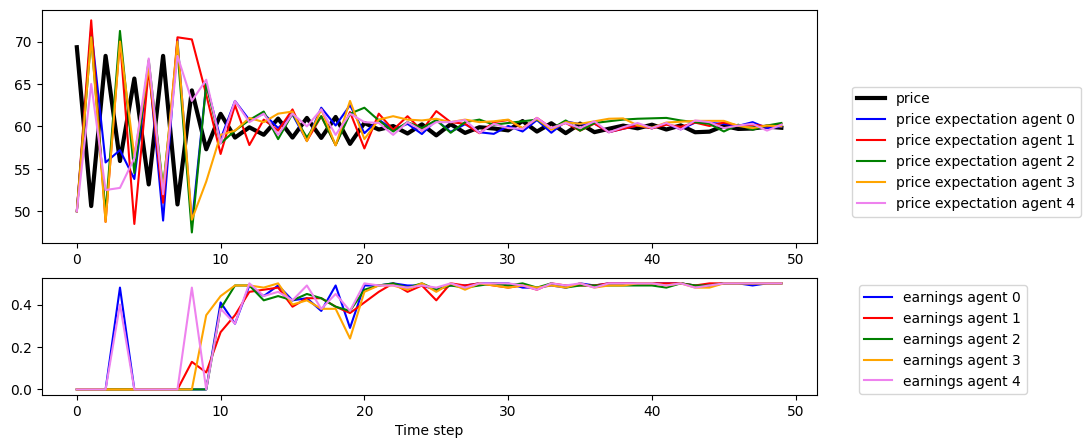

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_array_on,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_agents_time_on[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(rewards_agents_time_on[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend(bbox_to_anchor=(1.35, 0.7))
axes[1].legend(bbox_to_anchor=(1.28, 1))

axes[1].set_xlabel("Time step")
# axes[0].set_xticks(range(n_steps))
# axes[1].set_xticks(range(n_steps))

In [3]:
a = mod.create_experiment_folder()

Created new experiment folder: ../results/experiments/experiment_20250204_170703
